In [1]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [3]:
df = pd.read_csv('suzuki_stock_data.csv')

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df = df.set_index('Date')

In [6]:
series = df['Close']

In [8]:
train_size = int(len(series) * 0.9)
train,test = series[:train_size], series[train_size:]
exog_train, exog_test = df[['Volume']][:train_size], df[['Volume']][train_size:]

In [9]:
model =SARIMAX(train,
               exog = exog_train,
               order = (2,1,2),
               seasonal_order = (1,1,1,5))
model_fit = model.fit(disp = False)

c:\Users\PREDATOR\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PREDATOR\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\PREDATOR\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\PREDATOR\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization fail

In [10]:
forecast = model_fit.forecast(steps = len(test), exog = exog_test)

c:\Users\PREDATOR\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\PREDATOR\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [12]:
rmse = mean_squared_error(test, forecast)
mae = mean_absolute_error(test, forecast)

In [13]:
rmse

259137.20066016013

In [14]:
mae

454.10771465479405

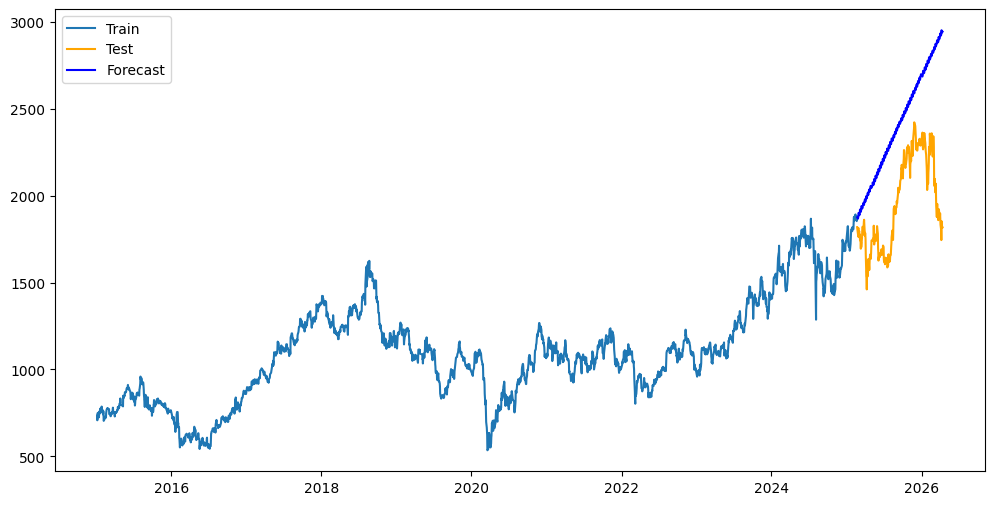

In [15]:
plt.figure(figsize = (12,6))
plt.plot(train.index, train, label = 'Train')
plt.plot(test.index, test, label = 'Test', color = 'orange')
plt.plot(test.index, forecast, label = 'Forecast', color = 'blue')
plt.legend()
plt.show()